In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

COLS = ["frame_id", "addr", "retcode", "distances", "raw_mm", "filtered_mm", "filtered_in", "p0_str", "tnow", "height_level"]

In [5]:
#useful functions
def parse_metadata(path):
    path = Path(path)

    if path.parent.name == "mobile_ground_dataset_calibrated":
        m = re.match(r"mobile_(\d+)_(\d+)\.txt", path.name)

        return {
            "environment": "ground_mobile",
            "bed": None,
            "height": int(m.group(1)),
            "point": None,
        }
    elif path.parent.name == "ground_mobile":
        m = re.match(r"mobile_(\d+)\.txt", path.name)

        return {
            "environment": "ground_mobile",
            "bed": None,
            "height": int(m.group(1)),
            "point": None,
        }

    m = re.match(r"mobile_(\d+)_(\d+)\.txt", path.name)

    return {
        "environment": "bed",
        "bed": int(path.parent.name.replace("bed", "")),
        "height": int(m.group(1)),
        "trial": int(m.group(2)),
    }
######################################################################################################################################################################################################
def read_log(path):
    df = pd.read_csv(path, names=COLS, skiprows=1)
    df["source_file"] = str(path)
    df["raw_valid"] = df["raw_mm"].replace(-1, np.nan)
    df["raw_in"] = df["raw_valid"] / 25.4
    df["filtered_valid_in"] = df["filtered_in"].where(df["raw_mm"] != -1)
    return df
######################################################################################################################################################################################################
def summarize_file(df, truth_in):
    '''
    if truth_in == 12:
        truth_manual = 11.59
    elif truth_in == 16:
        truth_manual = 15.58
    elif truth_in == 20:
        truth_manual = 19.83
    '''

    raw_err = df["raw_in"] - truth_in
    filt_err = df["filtered_valid_in"] - truth_in

    return {
        "samples": len(df),
        "valid_samples": df["raw_valid"].notna().sum(),
        "invalid_samples": df["raw_valid"].isna().sum(),
        "invalid_pct": (100 * df["raw_valid"].isna().mean()).round(3),

        "raw_mean": df["raw_in"].mean().round(3),
        "raw_median": df["raw_in"].median().round(3),
        "raw_std": df["raw_in"].std().round(3),
        "raw_bias": raw_err.mean().round(3),
        "raw_mae": raw_err.abs().mean().round(3),
        "raw_rmse": np.sqrt((raw_err ** 2).mean()).round(3),

        "filtered_mean": df["filtered_valid_in"].mean().round(3),
        "filtered_median": df["filtered_valid_in"].median().round(3),
        "filtered_std": df["filtered_valid_in"].std().round(3),
        "filtered_bias": filt_err.mean().round(3),
        "filtered_mae": filt_err.abs().mean().round(3),
        "filtered_rmse": np.sqrt((filt_err ** 2).mean()).round(3),
    }

In [7]:
rows = []
for file in Path("mobile_ground_dataset_calibrated").rglob("*.txt"):
    meta = parse_metadata(file)
    df = read_log(file)
    stats = summarize_file(df, meta["height"])

    rows.append({**meta,"file": file.name,**stats,})

summary = pd.DataFrame(rows)
summary.to_csv("mobile_g_calibrated_summary_out.csv", index=False)
summary.head()

,environment,bed,height,point,file,samples,valid_samples,invalid_samples,invalid_pct,raw_mean,...,raw_std,raw_bias,raw_mae,raw_rmse,filtered_mean,filtered_median,filtered_std,filtered_bias,filtered_mae,filtered_rmse
0,ground_mobile,None,12,None,mobile_12_1.txt,198,193,5,2.525,13.124,...,0.482,1.124,1.125,1.223,13.078,13.055,0.315,1.078,1.078,1.123
1,ground_mobile,None,16,None,mobile_16_1.txt,177,169,8,4.520,16.341,...,0.494,0.341,0.422,0.599,16.264,16.276,0.245,0.264,0.310,0.359
2,ground_mobile,None,20,None,mobile_20_1.txt,172,148,24,13.953,20.707,...,0.622,0.707,0.736,0.940,20.599,20.605,0.300,0.599,0.601,0.670


In [52]:
print("=================================")

# General Validity Statistics

total_samples = summary["samples"].sum()
total_valid = summary["valid_samples"].sum()
total_invalid = summary["invalid_samples"].sum()

overall_valid_pct = (100 * total_valid / total_samples).round(3)
overall_invalid_pct = (100 * total_invalid / total_samples).round(3)

runs_zero_invalid = (summary["invalid_pct"] == 0).sum()
runs_below_5_invalid = (summary["invalid_pct"] < 5).sum()
runs_above_20_invalid = (summary["invalid_pct"] >= 20).sum()

print("Total samples:", total_samples)
print("Total valid:", total_valid)
print("Total invalid:", total_invalid)
print(f"Overall valid: {overall_valid_pct} %")
print(f"Overall invalid: {overall_invalid_pct} %")
print("Runs with 0% invalid:", runs_zero_invalid)
print("Runs with <5% invalid:", runs_below_5_invalid)
print("Runs with >=20% invalid:", runs_above_20_invalid)

print("=================================")

# Standard Deviation Stats

# Print the number of runs that had an improved standard deviation
std_improved_runs = (summary["filtered_std"] < summary["raw_std"]).sum()
print("STD improved:", std_improved_runs, "/", len(summary), "runs")

# Print the median of all raw_std 
print("Median of raw_std: " + str(summary["raw_std"].median()) + " in.")

# Print the median of all filtered_std
print("Median of filtered_std: " + str(summary["filtered_std"].median()) + " in.")

print("=================================")

# MAE Stats

# Print the number of runs that had an improved MAE
mae_improved_runs = (summary["filtered_mae"] < summary["raw_mae"]).sum()
print("MAE improved:", mae_improved_runs, "/", len(summary), "runs")

# Print the median of all raw_mae
print("Median of raw_mae: " + str(summary["raw_mae"].median()) + " in.")

# Print the median of all filtered_mae
print("Median of filtered_mae: " + str(summary["filtered_mae"].median()) + " in.")

print("=================================")

# RMSE Stats

# Print the number of runs that had an improved RMSE
rmse_improved_runs = (summary["filtered_rmse"] < summary["raw_rmse"]).sum()
print("RMSE improved:", rmse_improved_runs, "/", len(summary), "runs")

# Print the median of all raw_rmse
print("Median of raw_rmse: " + str(summary["raw_rmse"].median()) + " in.")

# Print the median of all filtered_rmse
print("Median of filtered_rmse: " + str(summary["filtered_rmse"].median()) + " in.")

print("=================================")

# Tolerance Statistics
within_0_5 = (
    summary["filtered_bias"].abs() <= 0.5
).sum()

within_1 = (
    summary["filtered_bias"].abs() <= 1.0
).sum()

within_2 = (
    summary["filtered_bias"].abs() <= 2.0
).sum()

print(f"Within 0.5 inch: {within_0_5} runs ({(100 * within_0_5/len(summary)).round(3)} %)")

print(f"Within 1 inch: {within_1} runs ({(100 * within_1/len(summary)).round(3)} %)")

print(f"Within 2 inches: {within_2} runs ({(100 * within_2/len(summary)).round(3)} %)")

print("=================================")

# Stability vs. Closeness (to reference) Statistics

stable_limit = 0.25
bias_limit = 0.5

summary["stable"] = (
    summary["filtered_std"] <= stable_limit
)

summary["close_to_reference"] = (
    summary["filtered_bias"].abs() <= bias_limit
)

summary["classification"] = np.select(
    [
        summary["stable"] & summary["close_to_reference"],
        summary["stable"] & ~summary["close_to_reference"],
        ~summary["stable"] & summary["close_to_reference"],
        ~summary["stable"] & ~summary["close_to_reference"],
    ],
    [
        "Stable, Close",
        "Stable, Offset",
        "Unstable, Close",
        "Unstable, Offset",
    ],
    default="unknown"
)

print(f"Stable Limit: {stable_limit} in.")
print(f"Bias Limit: {bias_limit} in.")
print(f"Stable, Close: {(summary["classification"] == "Stable, Close").sum()}")
print(f"Stable, Offset: {(summary["classification"] == "Stable, Offset").sum()}")
print(f"Unstable, Close: {(summary["classification"] == "Unstable, Close").sum()}")
print(f"Unstable, Offset: {(summary["classification"] == "Unstable, Offset").sum()}")

print("=================================")

Total samples: 1553
Total valid: 1418
Total invalid: 135
Overall valid: 91.307 %
Overall invalid: 8.693 %
Runs with 0% invalid: 0
Runs with <5% invalid: 3
Runs with >=20% invalid: 0
STD improved: 9 / 9 runs
Median of raw_std: 1.995 in.
Median of filtered_std: 1.206 in.
MAE improved: 5 / 9 runs
Median of raw_mae: 2.276 in.
Median of filtered_mae: 2.424 in.
RMSE improved: 9 / 9 runs
Median of raw_rmse: 2.816 in.
Median of filtered_rmse: 2.666 in.
Within 0.5 inch: 0 runs (0.0 %)
Within 1 inch: 0 runs (0.0 %)
Within 2 inches: 3 runs (33.333 %)
Stable Limit: 0.25 in.
Bias Limit: 0.5 in.
Stable, Close: 0
Stable, Offset: 0
Unstable, Close: 0
Unstable, Offset: 9


Invalid % vs raw STD: 0.996
Invalid % vs filtered STD: 0.154


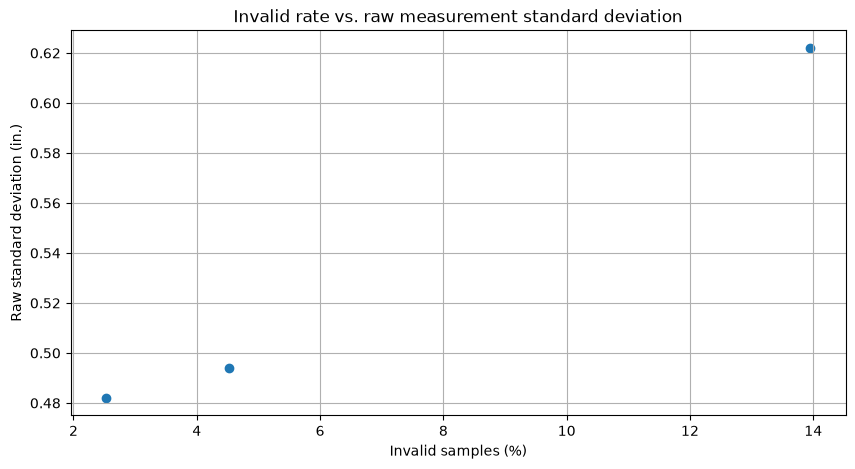

In [42]:
import matplotlib.pyplot as plt

# For looking at the correlation between invalid readings and standard deviations
raw_corr = summary["invalid_pct"].corr(summary["raw_std"]).round(3)
filtered_corr = summary["invalid_pct"].corr(summary["filtered_std"]).round(3)

print("Invalid % vs raw STD:", raw_corr)
print("Invalid % vs filtered STD:", filtered_corr)

plt.figure(figsize=(10, 5))

plt.scatter(
    summary["invalid_pct"],
    summary["raw_std"]
)

'''
Annotations (use if needed)
for _, row in summary.iterrows():
    label = (
        f"B{int(row['bed'])}-"
        f"{int(row['height'])}-"
        f"P{int(row['point'])}"
    )

    plt.annotate(
        label,
        (row["invalid_pct"], row["raw_std"]),
        fontsize=8,
    )
'''

plt.xlabel("Invalid samples (%)")
plt.ylabel("Raw standard deviation (in.)")
plt.title("Invalid rate vs. raw measurement standard deviation")
plt.grid(True)
plt.show()


In [43]:
# Improvement percentages for standard deviation and RMSE (run-level, grouped by height)
summary["std_improvement_pct"] = (
    (summary["raw_std"] - summary["filtered_std"]) / summary["raw_std"]
) * 100

summary["rmse_improvement_pct"] = (
    (summary["raw_rmse"] - summary["filtered_rmse"]) / summary["raw_rmse"]
) * 100

# summary[["std_improvement_pct", "rmse_improvement_pct"]] <--- just to see all runs and their corresponding improvements

summary.groupby("height")[["std_improvement_pct", "rmse_improvement_pct"]].mean().round(1)

,std_improvement_pct,rmse_improvement_pct
height,,
12,34.6,-24.4
16,50.4,-21.2
20,51.8,12.2


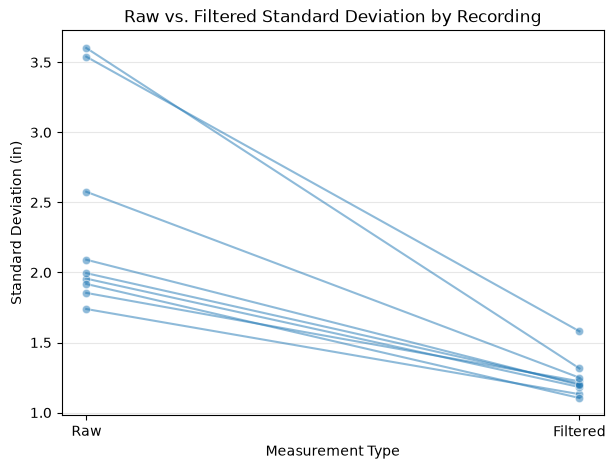

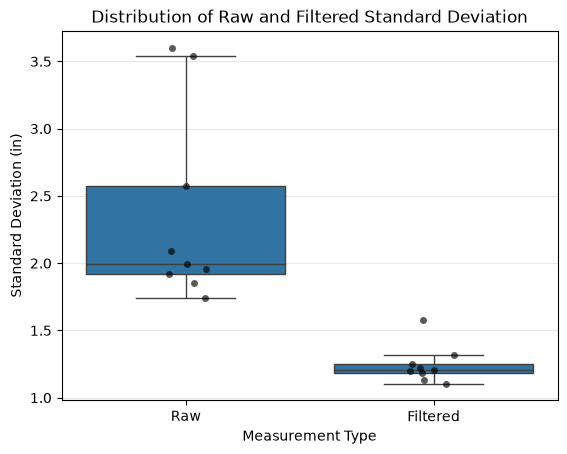

In [27]:
import seaborn as sns

# Give each recording an ID
plot_data = summary.copy()
plot_data["run"] = plot_data.index

# Convert raw_std and filtered_std into long format
std_long = plot_data.melt(
    id_vars="run",
    value_vars=["raw_std", "filtered_std"],
    var_name="measurement_type",
    value_name="standard_deviation"
)

# Replace column names with cleaner plot labels
std_long["measurement_type"] = std_long["measurement_type"].replace({
    "raw_std": "Raw",
    "filtered_std": "Filtered"
})

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=std_long,
    x="measurement_type",
    y="standard_deviation",
    units="run",
    estimator=None,
    marker="o",
    alpha=0.5
)

plt.xlabel("Measurement Type")
plt.ylabel("Standard Deviation (in)")
plt.title("Raw vs. Filtered Standard Deviation by Recording")
plt.grid(axis="y", alpha=0.3)
plt.show()

sns.boxplot(
    data=std_long,
    x="measurement_type",
    y="standard_deviation",
    showfliers=False
)

sns.stripplot(
    data=std_long,
    x="measurement_type",
    y="standard_deviation",
    color="black",
    alpha=0.65,
    jitter=True
)

plt.xlabel("Measurement Type")
plt.ylabel("Standard Deviation (in)")
plt.title("Distribution of Raw and Filtered Standard Deviation")
plt.grid(axis="y", alpha=0.3)
plt.show()

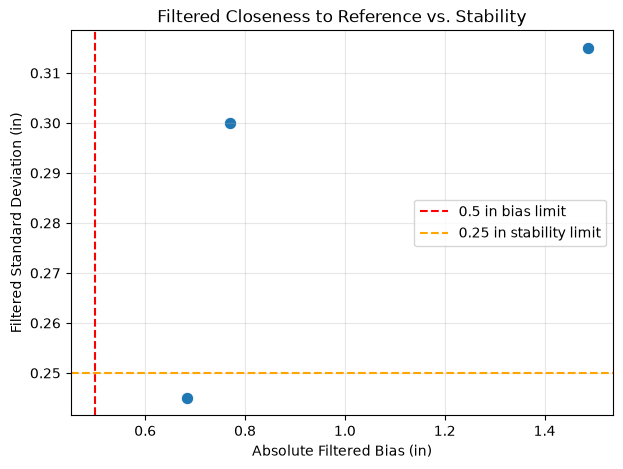

In [44]:
# Convert signed bias to error magnitude
summary["abs_filtered_bias"] = summary["filtered_bias"].abs()

plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=summary,
    x="abs_filtered_bias",
    y="filtered_std",
    s=80
)

# Classification thresholds
plt.axvline(
    0.5,
    color="red",
    linestyle="--",
    label="0.5 in bias limit"
)

plt.axhline(
    0.25,
    color="orange",
    linestyle="--",
    label="0.25 in stability limit"
)

plt.xlabel("Absolute Filtered Bias (in)")
plt.ylabel("Filtered Standard Deviation (in)")
plt.title("Filtered Closeness to Reference vs. Stability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()